<a href="https://colab.research.google.com/github/thekylebell/Momentum-Models/blob/feature%2Fvol-targeting/Momentum-Models/feature/vol-targeting" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This notebook serves as a template for building Time Series Momentum models. We will build the model step by step, explaining what each step achieves and why it is necessary. This version includes the introduction of a "Risk Engine" that asks, "Even if I want to be in the market, how much can I safely handle right now?"

A Time-series momentum (or Absolute Momentum) is a simple model that follows market trends. It does not compare itself to other assets, only how it is performing relative to its past. The core idea is that if the model shows positive growth over the specified time period (e.g., 3 months or 12 months), then you buy it. If it is negative, you exit or go to cash. You are betting that the price trend will continue.




Lets build the Model!

In [2]:
#Start by importing the libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


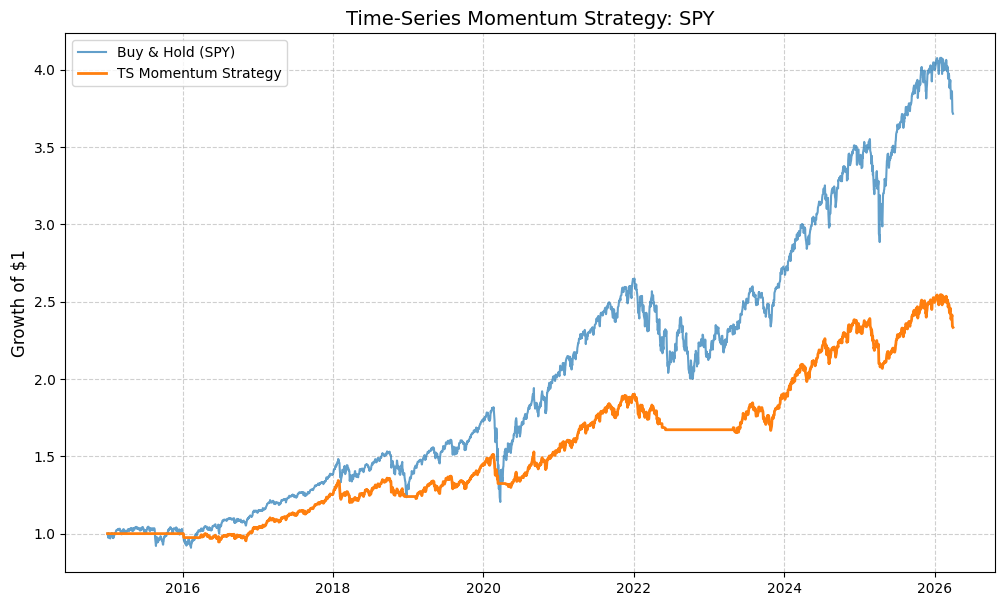

Total Strategy Return: 133.37%


In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np # <-- New: Needed for math operations

# --- 1. CONFIGURATION ---
ticker = 'SPY'
lookback_days = 252  # 1 year of trading days
start_date = '2015-01-01'

#NEW: Volatility Targeting Parameters
#This sets our risk budget (12% annualized) and how far back we look for risk.
target_vol = .12
vol_lookback = 20

# --- 2. DATA ACQUISITION ---
# auto_adjust=False ensures we get the 'Adj Close' column explicitly
df = yf.download(ticker, start=start_date, auto_adjust=False)

# Flatten MultiIndex (yfinance 2026 fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only the adjusted close price and make a copy to avoid warnings
df = df[['Adj Close']].copy()

# --- 3. MODEL LOGIC ---
# Momentum: (Current Price / Price N days ago) - 1
df['momentum'] = (df['Adj Close'] / df['Adj Close'].shift(lookback_days)) - 1

# Signal: 1 (Long) if momentum > 0, else 0 (Cash)
df['signal'] = (df['momentum'] > 0).astype(int)

#NEW: Volatility Scaling
#Calculates the actual market risk (Std Deviation) and determines our position size (Weight)
df['benchmark_return'] = df['Adj Close'].pct_change()
df['realized_vol'] = df['benchmark_return'].rolling(window=vol_lookback).std() * np.sqrt(252)
df['vol_weight'] = (target_vol / df['realized_vol']).clip(upper=1.0)

#NEW: Combined Position
#Final position is 'Trend Direction' x 'Risk-Adjusted Weight'.
df['scaled_position'] = df['signal'] * df['vol_weight']

# --- 4. PERFORMANCE CALCULATION ---
#NEW: We shift the 'scaled_position' to avoid look-ahead bias.
#In professional backtesting, you rarely go from a signal to a trade. There is usually a Scaling Step
# in between which determines how much to buy based on volatility, portfolio heat, or available capital.
#While no Risk Engine or Sizing section is included in this model, the changes are made to reflect
#an upcoming model where we ask users for inputs then show them how their model performed.
df['position_lagged'] = df['scaled_position'].shift(1)
df['strategy_return'] = df['benchmark_return'] * df['position_lagged']

# --- 5. VISUALIZATION ---
# Growth of $1 (Cumulative Product)
# We fill NaN with 0 for the first return to start at exactly 1.0
performance = (1 + df[['benchmark_return', 'strategy_return']].fillna(0)).cumprod()

plt.figure(figsize=(12, 7))
plt.plot(performance['benchmark_return'], label='Buy & Hold (SPY)', alpha=0.7)
plt.plot(performance['strategy_return'], label='TS Momentum Strategy', linewidth=2)
plt.title(f"Time-Series Momentum Strategy: {ticker}", fontsize=14)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 6. BASIC METRICS ---
total_ret = (performance['strategy_return'].iloc[-1] - 1) * 100
print(f"Total Strategy Return: {total_ret:.2f}%")